# Семинар

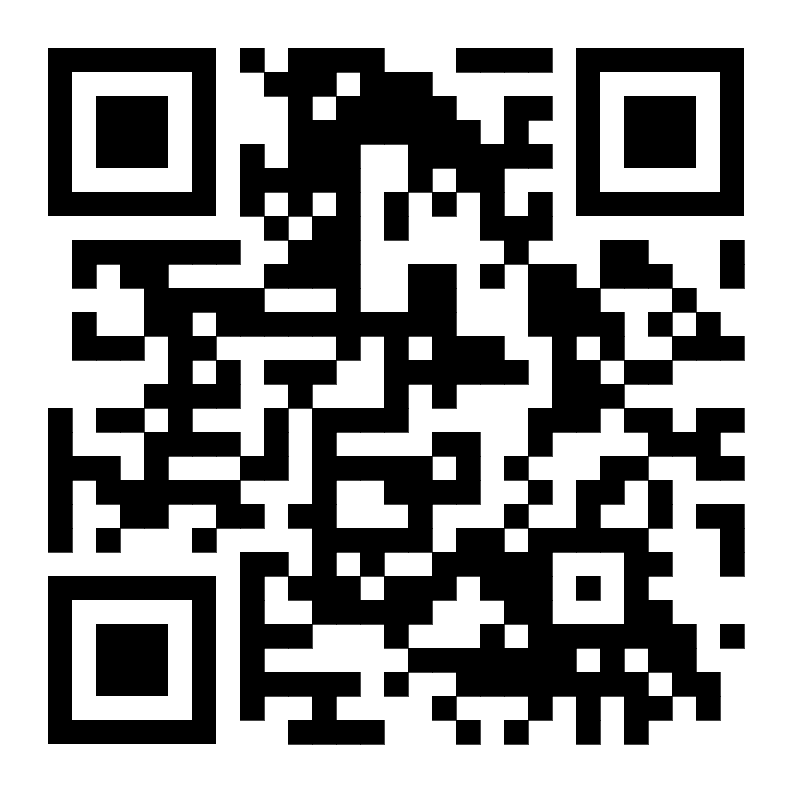

# Знакомство, формат семинаров и правила оценки

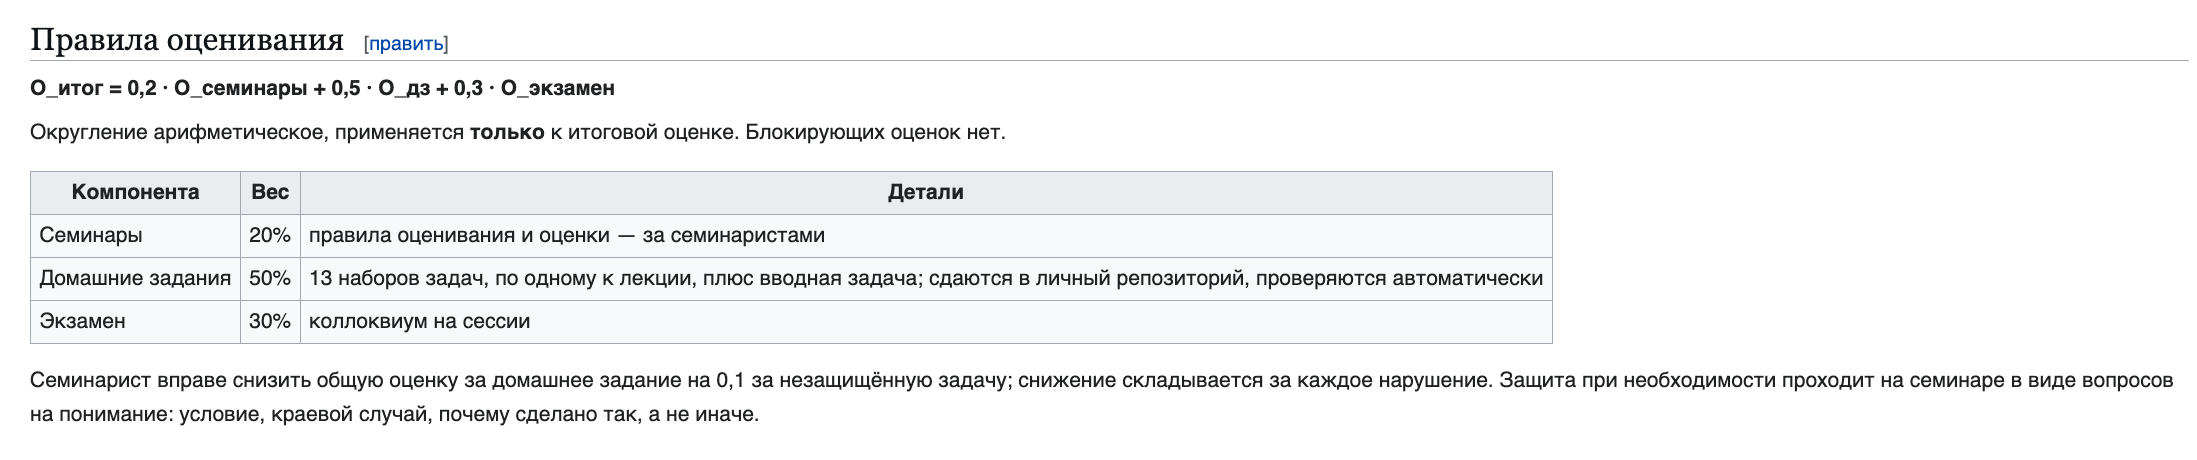
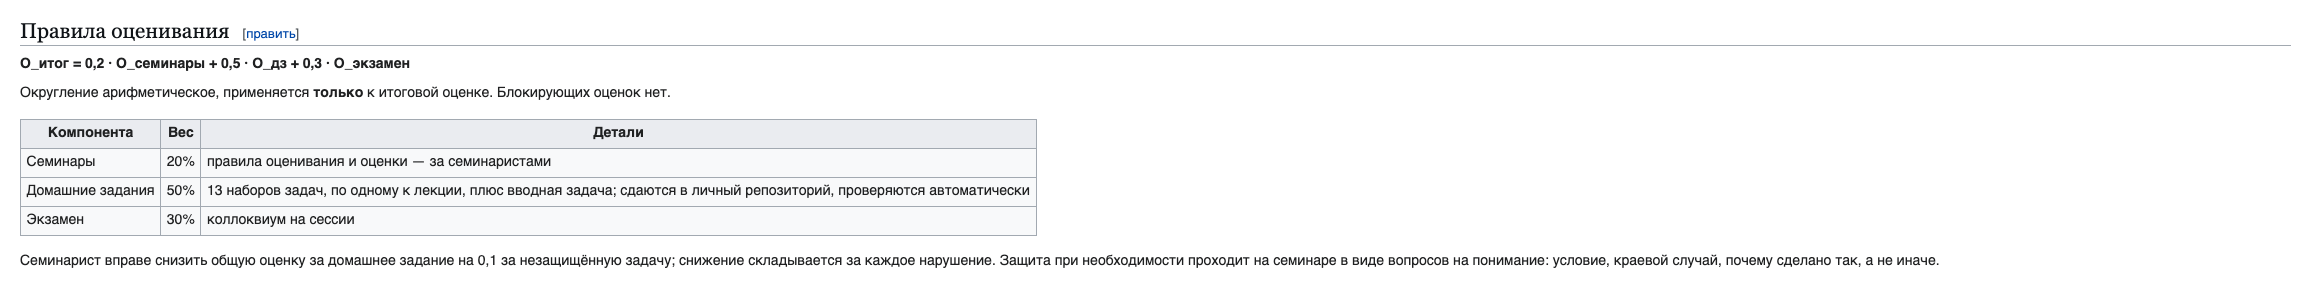

## Пару слов про Python

- [Ten things people want to know about Python](https://wiki.python.org/moin/Ten%20things%20people%20want%20to%20know%20about%20Python)
- [PEP8](https://peps.python.org/pep-0008/)

- Why is Python a dynamic language and also a strongly typed language?

  In a weakly typed language a compiler / interpreter will sometimes change the type of a variable. For example, in some languages (like JavaScript) you can add strings to numbers 'x' + 3 becomes 'x3'. This can be a problem because if you have made a mistake in your program, instead of raising an exception execution will continue but your variables now have wrong and unexpected values. In a strongly typed language (like Python) you can't perform operations inappropriate to the type of the object - attempting to add numbers to strings will fail. Problems like these are easier to diagnose because the exception is raised at the point where the error occurs rather than at some other, potentially far removed, place.
  
  In a statically typed language, the type of variables must be known (and usually declared) at the point at which it is used. Attempting to use it will be an error. In a dynamically typed language, objects still have a type, but it is determined at runtime. You are free to bind names (variables) to different objects with a different type. So long as you only perform operations valid for the type the interpreter doesn't care what type they actually are. 

- Any good Python book?

  - Mark Lutz,  Learning Python, 5th Edition 

- Why separate sections by indentation instead of by brackets or 'end'

  As indentation is better for humans, it makes sense to use that for the compiler too

- Why is Python slower than the xxx language

  In general you can't compare the speed of one language to another - you can only compare implementations.

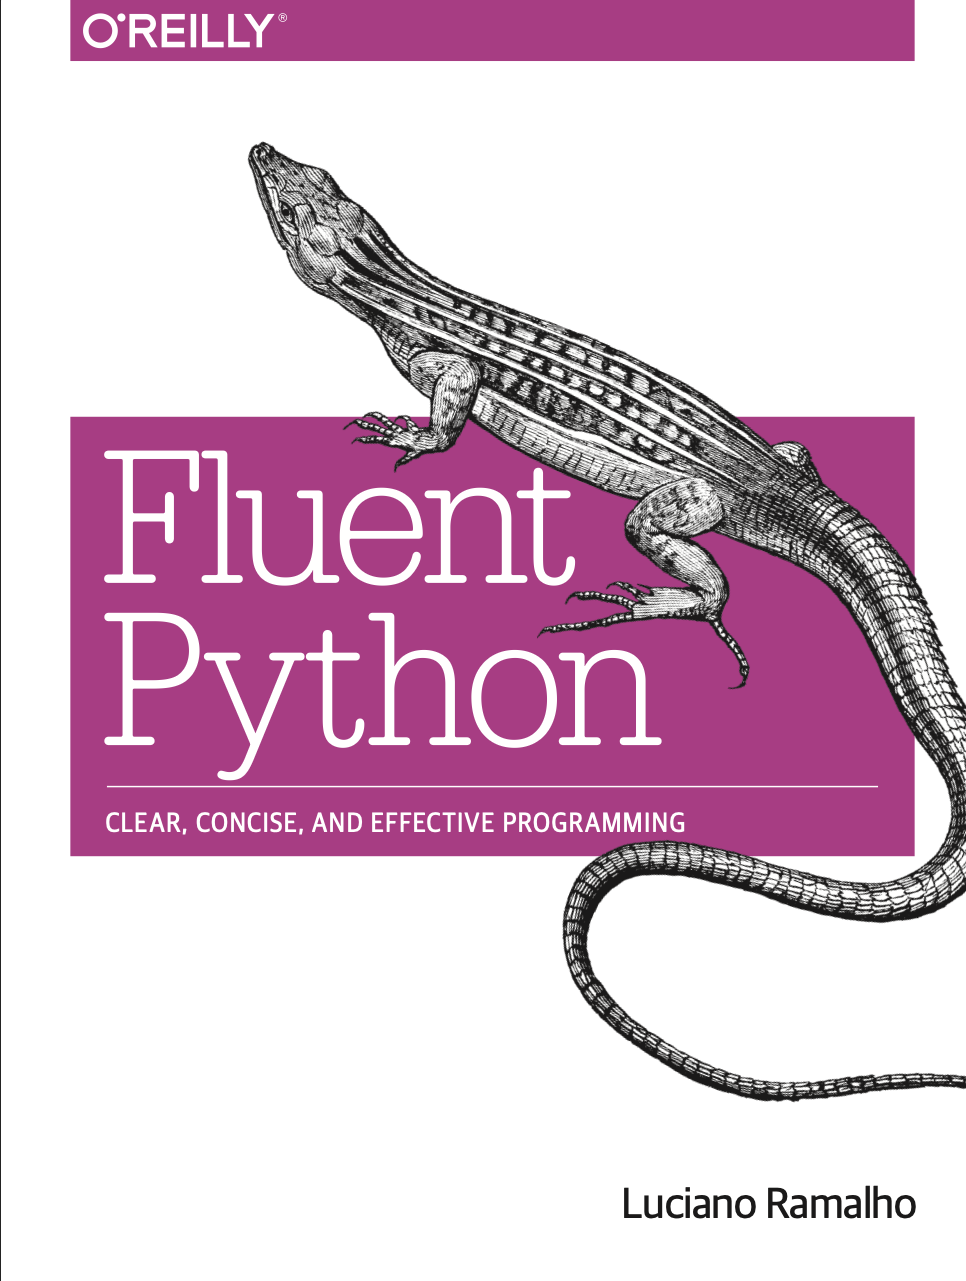

In [1]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


## Недосказанное

Если вы хотите сами поиграться и посмотреть что быстрее, а что медленнее, то вот пример как лучше всего замерять время работы кусков кода:

In [2]:
import time


def measure_performance():
    n = 1000000

    start1 = time.perf_counter()
    result1 = []
    for i in range(n):
        result1.append(i * 2)
    end1 = time.perf_counter()

    start2 = time.perf_counter()
    _ = [i * 2 for i in range(n)]
    end2 = time.perf_counter()

    print(f"Цикл for: {end1 - start1:.6f} секунд")
    print(f"List comprehension: {end2 - start2:.6f} секунд")
    print(f"Разница: {(end1 - start1) - (end2 - start2):.6f} секунд")
    print(f"List comprehension быстрее в {((end1 - start1) / (end2 - start2)):.2f} раз")


measure_performance()

Цикл for: 0.024038 секунд
List comprehension: 0.077539 секунд
Разница: -0.053501 секунд
List comprehension быстрее в 0.31 раз


В ячейках ноутбука можно делать бенчмарки при помощи магии `timeit`:

In [3]:
%%timeit

result1 = []
for i in range(1_000_000):
    result1.append(i * 2)

25.4 ms ± 681 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


### _ в ноутбуках и python shell

In [4]:
1

1

In [5]:
_ #  в переменную _ в интерактивном режиме записывается результат последнего выражения

1

In [6]:
_ + 2

3

In [7]:
_ ** 2

9

Какая еще магия есть в тетрадках?

`%who` - список всех переменных в актуальном состоянии неймспеса.

In [8]:
%who

measure_performance	 this	 time	 


`%whos` - список всех переменных с указанием типа в актуальном состоянии неймспеса.

In [9]:
%whos

Variable              Type        Data/Info
-------------------------------------------
measure_performance   function    <function measure_performance at 0x10a31cf60>
this                  module      <module 'this' from '/opt<...>/lib/python3.14/this.py'>
time                  module      <module 'time' (built-in)>


`%pinfo` - получение подробной информации об объекте из неймспейса.

In [10]:
%pinfo timeit

Docstring:
Time execution of a Python statement or expression

**Usage, in line mode**::

  %timeit [-n<N> -r<R> [-t|-c] -q -p<P> [-o|-v <V>]] statement

**or in cell mode**::

  %%timeit [-n<N> -r<R> [-t|-c] -q -p<P> [-o|-v <V>]] setup_code
  code
  code...

Time execution of a Python statement or expression using the timeit
module.  This function can be used both as a line and cell magic:

- In line mode you can time a single-line statement (though multiple
  ones can be chained with using semicolons).

- In cell mode, the statement in the first line is used as setup code
  (executed but not timed) and the body of the cell is timed.  The cell
  body has access to any variables created in the setup code.

Options:

-n<N>
  Execute the given statement N times in a loop. If N is not
  provided, N is determined so as to get sufficient accuracy.

-r<R>
  Number of repeats R, each consisting of N loops, and take the
  average result.
  Default: 7

-t
  Use ``time.time`` to measure the time

### Unicode

In [11]:
print(*[chr(i) for i in range(ord("a"), ord("z") + 1)])

a b c d e f g h i j k l m n o p q r s t u v w x y z


In [12]:
print(*[chr(i) for i in range(ord("A"), ord("Z") + 1)])

A B C D E F G H I J K L M N O P Q R S T U V W X Y Z


In [13]:
print(*[chr(i) for i in range(ord("α"), ord("ω") + 1)])

α β γ δ ε ζ η θ ι κ λ μ ν ξ ο π ρ ς σ τ υ φ χ ψ ω


In [14]:
import unicodedata


def char_info(char):
    return {
        "char": char,
        "code_point": ord(char),
        "name": unicodedata.name(char, "Unknown"),
    }


print(char_info("A"))
print(char_info("😊"))
print(char_info("π"))

{'char': 'A', 'code_point': 65, 'name': 'LATIN CAPITAL LETTER A'}
{'char': '😊', 'code_point': 128522, 'name': 'SMILING FACE WITH SMILING EYES'}
{'char': 'π', 'code_point': 960, 'name': 'GREEK SMALL LETTER PI'}


### Битовые операции

![bitwise_operation](images/bitwise_operations.png)

In [15]:
1 << 10, 8 >> 2

(1024, 2)

In [16]:
0b101 ^ 0b010, 0b010 | 0b011, 0b011 & 0b110

(7, 3, 2)

In [18]:
0xdeadbeef

3735928559

In [17]:
0o123

83

In [20]:
bin(1000)

'0b1111101000'

In [21]:
bin(0b101 ^ 0b010), bin(0b010 | 0b011), bin(0b011 & 0b110)

('0b111', '0b11', '0b10')

In [22]:
hex(123)

'0x7b'

In [23]:
oct(123)

'0o173'

### Комплексные числа

In [24]:
complex

complex

In [25]:
a = complex(4, 3)
a, type(a)

((4+3j), complex)

In [26]:
a = 4 + 3j
a, type(a)

((4+3j), complex)

In [27]:
a.real, a.imag

(4.0, 3.0)

In [28]:
a = 1 + 2j
b = 2 + 4j
print('Addition =', a + b)
print('Subtraction =', a - b)
print('Multiplication =', a * b)
print('Division =', a / b)

Addition = (3+6j)
Subtraction = (-1-2j)
Multiplication = (-6+8j)
Division = (0.5+0j)


### Множественное сравнение

In [29]:
1 < 2 < 3 < 4 < 5

True

In [33]:
1 < 2 and 2 < 3 and 3 < 4 and 4 < 5

True

### Непонятные выражения

In [34]:
# Какой ответ?
True != False == False

True

In [35]:
# Как это работает:
(True != False) and (False == False)

True

### Строки

In [36]:
a = """
Здесь можно так
    и так
            вот это да
    вот
"""
a

'\nЗдесь можно так\n    и так\n            вот это да\n    вот\n'

In [39]:
import textwrap


print(
    textwrap.dedent(
        """
        1\t2\t3\n
        4\t5\t6\n
        """
    )
)


1	2	3

4	5	6




In [40]:
print(a)


Здесь можно так
    и так
            вот это да
    вот



### Перенос строк

In [45]:
(
    'Hello, '
    'world!'
)

'Hello, world!'

In [43]:
'Hello, ' + \
'world' + \
'!'

'Hello, world!'

In [44]:
'Hello, ' \
'world' \
'!'

'Hello, world!'

### Форматирование строк

In [46]:
words = ('Hello', 'Goodbye')
names = ('Vanya', 'Stepa')

In [48]:
for word in words:
    for name in names:
        print('%s, %s!' % (word, name))
        print('{}, {}!'.format(word, name))
        print(f'{word}, {name}!')
        print()

Hello, Vanya!
Hello, Vanya!
Hello, Vanya!

Hello, Stepa!
Hello, Stepa!
Hello, Stepa!

Goodbye, Vanya!
Goodbye, Vanya!
Goodbye, Vanya!

Goodbye, Stepa!
Goodbye, Stepa!
Goodbye, Stepa!



In [49]:
word = 'Hello'
name = 'Vanya'

In [53]:
print('{1}, {0}!'.format(name, word))
print('{word}, {name}!'.format(word=word, name=name))
print('{0}, {name}!'.format(word, name=name))

Hello, Vanya!
Hello, Vanya!
Hello, Vanya!


In [54]:
print(f'''Hello!
My name is {name}.''')

Hello!
My name is Vanya.


In [59]:
float_number = 3.1415
print('%d' % float_number)
print('%f' % float_number)
print('{}'.format(float_number))
print(f'{float_number}')
print(f'{float_number:.3f}')
print('%.3f' % float_number)
print('{:.3f}'.format(float_number))
print(f'{float_number:.7}')

3
3.141500
3.1415
3.1415
3.142
3.142
3.142
3.1415


In [56]:
a = 1
print(f'{a:04d}')
print(f'{a:04}')

0001
0001


### Переопределение стандартного типа/функции

In [60]:
dir(__builtins__)

['ArithmeticError',
 'AssertionError',
 'AttributeError',
 'BaseException',
 'BaseExceptionGroup',
 'BlockingIOError',
 'BrokenPipeError',
 'BufferError',
 'BytesWarning',
 'ChildProcessError',
 'ConnectionAbortedError',
 'ConnectionError',
 'ConnectionRefusedError',
 'ConnectionResetError',
 'DeprecationWarning',
 'EOFError',
 'Ellipsis',
 'EncodingWarning',
 'EnvironmentError',
 'Exception',
 'ExceptionGroup',
 'False',
 'FileExistsError',
 'FileNotFoundError',
 'FloatingPointError',
 'FutureWarning',
 'GeneratorExit',
 'IOError',
 'ImportError',
 'ImportWarning',
 'IndentationError',
 'IndexError',
 'InterruptedError',
 'IsADirectoryError',
 'KeyError',
 'KeyboardInterrupt',
 'LookupError',
 'MemoryError',
 'ModuleNotFoundError',
 'NameError',
 'None',
 'NotADirectoryError',
 'NotImplemented',
 'NotImplementedError',
 'OSError',
 'OverflowError',
 'PendingDeprecationWarning',
 'PermissionError',
 'ProcessLookupError',
 'PythonFinalizationError',
 'RecursionError',
 'ReferenceError',

In [61]:
str = 'hello'
str(1)

TypeError: 'str' object is not callable

In [62]:
str_ = 1


In [63]:
str = __builtins__.str

### Листы и самозацикливание

In [64]:
a = ["a", "b", "c", 1, 1.0, 3]  # так делать не очень хорошо

In [65]:
a = [1, 2, 3, 4]

In [66]:
a.append(a)

In [67]:
a[-1][-1][-1]

[1, 2, 3, 4, [...]]

In [68]:
a[-1][-1][0]

1

In [69]:
a[0] = 1

In [70]:
a[0], a[-1][0]

(1, 1)

### Конвертация типов

In [71]:
1 + '1'

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [73]:
True + 1

2

In [74]:
1 + 1.0

2.0

In [75]:
type(1 + 1.0)

float

In [76]:
True + 1.0

2.0

In [ ]:
True == 1, "1" == 1, 1.0 == 1

(True, False, True)

In [78]:
bool(-100.0), bool(0.0), bool(1000.0)

(True, False, True)

In [79]:
bool(""), bool("True"), bool("False"), bool("[]")

(False, True, True, True)

In [80]:
bool([]), bool([10, 20, 30]), bool([True]), bool([False])

(False, True, True, True)

In [81]:
bool(()), bool((False)), bool((False,))

(False, False, True)

In [82]:
list("abc")

['a', 'b', 'c']

In [83]:
float("-inf"), float("inf")

(-inf, inf)

### Кортежи

In [87]:
print((1, 2) + (3, 4))
print((True, False) * 10)

(1, 2, 3, 4)
(True, False, True, False, True, False, True, False, True, False, True, False, True, False, True, False, True, False, True, False)


In [88]:
print((1, 2) + (3))

TypeError: can only concatenate tuple (not "int") to tuple

In [89]:
print((20, 30) + (40,))

(20, 30, 40)


### Packing, unpacking

In [90]:
a = map(int, input().split())
print(type(a))

<class 'map'>


In [92]:
a, b = map(int, input().split()) # да, так можно сделать с несколькими переменными одновременно
h = list(map(int, input().split()))
print(a, b, type(a), type(b))
print(h, type(h))

1 2 <class 'int'> <class 'int'>
[] <class 'list'>


In [100]:
colors = ('red', 'green', 'blue')
*other_colors, blue = colors

In [102]:
blue

'blue'

In [103]:
other_colors

['red', 'green']

In [104]:
letters = 'abcdefgh'
*other, prev, last = letters

In [105]:
other

['a', 'b', 'c', 'd', 'e', 'f']

In [106]:
prev

'g'

In [107]:
last

'h'

Ниже хороший пример взаимодействия с кортежами и как можно распаковывать хранящиеся в них данные:

In [108]:
metro_areas = [
    ("Tokyo", "JP", 36.933, (35.689722, 139.691667)),
    ("Delhi NCR", "IN", 21.935, (28.613889, 77.208889)),
    ("Mexico City", "MX", 20.142, (19.433333, -99.133333)),
    ("New York-Newark", "US", 20.104, (40.808611, -74.020386)),
    ("São Paulo", "BR", 19.649, (-23.547778, -46.635833)),
]

print(f"{'':15} | {'latitude':>9} | {'longitude':>9}")
for name, _, _, (lat, lon) in metro_areas:
    if lon <= 0:
        print(f"{name:15} | {lat:9.4f} | {lon:9.4f}")

                |  latitude | longitude
Mexico City     |   19.4333 |  -99.1333
New York-Newark |   40.8086 |  -74.0204
São Paulo       |  -23.5478 |  -46.6358


### Ленивое вычисления and и or

In [109]:
print(0 and NEVER_EXISTED_VARIABLE)
print([10] or NEVER_EXISTED_VARIABLE)

0
[10]


In [110]:
bool(None)

False

In [111]:
print(10) or print("lazy")

10
lazy


### None

In [112]:
None

In [113]:
type(None)

NoneType

### Моржовый оператор (:=)

In [115]:
z = (x := (1 + 2 + 3 + 4)) + (y := 30)
x, y, z

(10, 30, 40)

### Namedtuple

In [116]:
from collections import namedtuple

Point = namedtuple('Point', ['x', 'y'])
p = Point(11, y=22)
p[0] + p[1], p.x + p.y

(33, 33)

### List comprehension

In [ ]:
a, b = map(int, input().split()) # да, так можно сделать с несколькими переменными одновременно
h = list(map(int, input().split()))
print(a, b, type(a), type(b))
print(h, type(h))

In [ ]:
a, b = [int(e) for e in input().split()]
a, b

In [ ]:
c = list()